In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kavyakatal/housing-dataset/Housing.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/kavyakatal/housing-dataset/Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
df.shape
# Checking number of rows and columns in housing dataset

(545, 13)

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.columns
# Checking all columns present in housing dataset

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.info()
# Checking datatypes in our dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.isnull().sum().sort_values(ascending=False)
# Checking missing values per column in our dataset

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# Checking count of duplicate rows in our dataset

Duplicate rows: 0


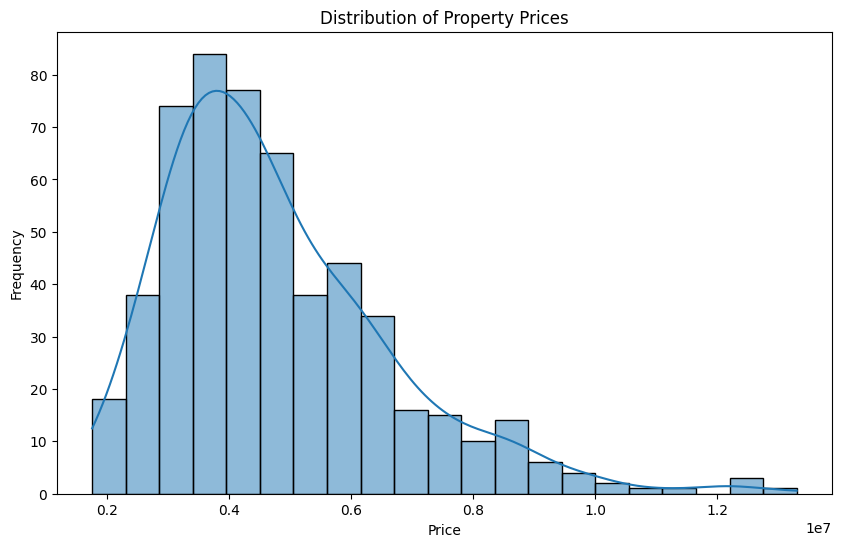

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(df["price"], kde=True)

plt.title("Distribution of Property Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

Observation:
Property prices show a slightly right-skewed distribution,
indicating the presence of high-value properties.

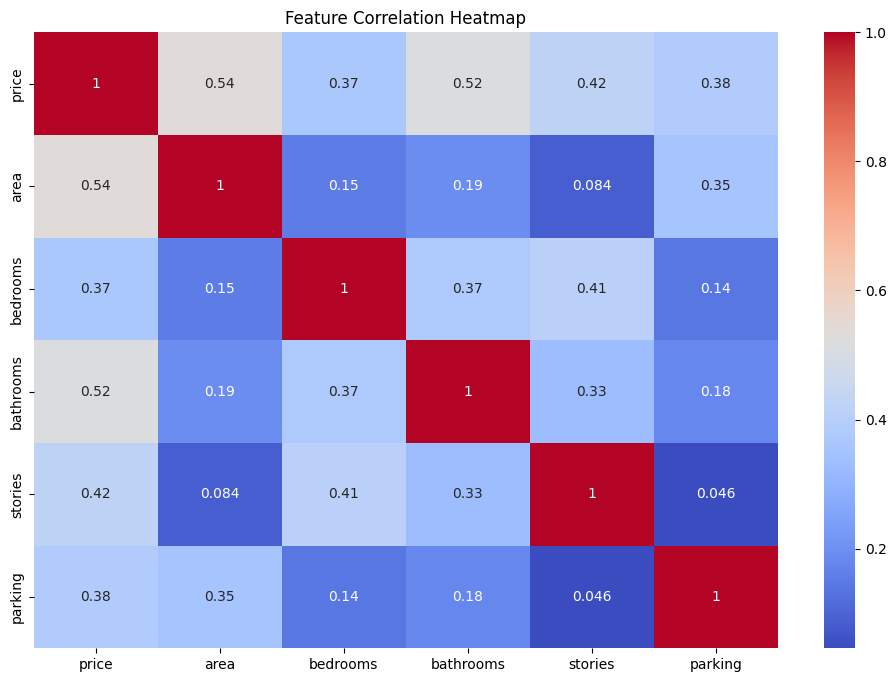

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Helps to check strongest factors/columns affecting our housing price

Observation:
Area shows the strongest positive correlation with price.
Bathrooms and number of stories also contribute significantly.

In [11]:
df_model = df.copy()
# Creating copy of df for safety

In [12]:
binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    df_model[col] = df_model[col].map({"yes":1, "no":0})

# Binary columns are columns have answer in YES/NO format hence binary and hence they require encoding to get converted in Numerical Format

Categorical variables were encoded using binary and ordinal encoding techniques to convert them into numerical form suitable for machine learning models. Binary attributes were mapped using 0 and 1 values, while furnishing status was ordinally encoded to preserve its natural ranking. This approach maintains meaningful relationships between feature categories that directly influence property pricing. One-hot encoding was avoided to prevent unnecessary feature expansion and reduce model complexity.

In [13]:
df_model["furnishingstatus"] = df_model["furnishingstatus"].map({
    "unfurnished":0,
    "semi-furnished":1,
    "furnished":2
})

# Encoding furnishing as it has ordinal data


In [14]:
df_model.head()
# Verifying encoded dataset

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


### TRAIN-TEST Split

### Feature and Target Separation

The dataset is divided into input features (X) and target variable (y).
The model learns relationships between housing attributes and property price.

In [15]:
X = df_model.drop("price", axis=1)
y = df_model["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (545, 12)
Target Shape: (545,)


### Train Test Split

Dataset is divided into training and testing sets to evaluate
model performance on unseen data.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (436, 12)
Testing Samples: (109, 12)


The dataset was split into 80% training data and 20% testing data.
A fixed random state was used to ensure reproducibility of results.

### Feature Scaling

Feature scaling standardizes numerical values so that all features
contribute equally during model training.
StandardScaler was used to normalize feature distributions.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [18]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(436, 12)
(109, 12)


# Scaling fitted only on training data to avoid data leakage.

### Linear Regression Model Training

Linear Regression was used as a baseline model to understand
linear relationships between housing features and property price.

In [19]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [20]:
y_pred_lr = lr_model.predict(X_test_scaled)
# Model Prediction
y_pred_lr

array([5203691.70963177, 7257004.02115475, 3062828.59668172,
       4559591.65374424, 3332932.30559783, 3563080.67918996,
       5645466.3121997 , 6413979.66873635, 2755831.54819001,
       2668938.6607523 , 9570600.29915351, 2827431.50860062,
       3195686.25834091, 3352263.99438472, 3713879.49996132,
       5301088.2443575 , 2987920.26669682, 4810799.8212371 ,
       4383031.70489929, 3525092.18938646, 5796259.50068013,
       5840000.702993  , 2760214.60864101, 4762590.14920608,
       5204755.73895204, 7515542.71619022, 3254681.68956383,
       5236164.45964445, 8178523.1682028 , 3434166.1567565 ,
       6443921.58767582, 3346004.77919185, 6742324.74004132,
       4154936.84088665, 3589152.47491253, 5788125.92515323,
       4768370.18154077, 4391684.04193173, 3217657.04549936,
       4638196.61928879, 4522160.27786713, 3541284.06127246,
       7238136.1194117 , 4021515.68926614, 3701978.76822756,
       4298879.55563098, 6705004.0206061 , 3993466.52296897,
       3798185.05328058,

### Model Evaluation

Model performance was evaluated using regression metrics
such as MAE, RMSE, and R² score.

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 979679.6912959908
RMSE: 1331071.4167895128
R2 Score: 0.6494754192267792


The MAE and RMSE values appear large because property prices
are measured in millions. When compared relative to the average
house price, the prediction error remains within a reasonable range
for a baseline Linear Regression model.

### Decision Tree Regression

Decision Tree Regression was implemented to capture
non-linear relationships between housing features and price.

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [23]:
y_pred_dt = dt_model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
MAE: 1270788.990825688
RMSE: 1718102.2400717163
R2 Score: 0.4159987568744603


### Decision Tree Optimization

Hyperparameters were tuned to reduce overfitting and
improve model generalization performance.

In [25]:
from sklearn.tree import DecisionTreeRegressor

dt_optimized = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_optimized.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [26]:
y_pred_dt_opt = dt_optimized.predict(X_test)

In [27]:
mae_opt = mean_absolute_error(y_test, y_pred_dt_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_dt_opt))
r2_opt = r2_score(y_test, y_pred_dt_opt)

print("Optimized Decision Tree")
print("MAE:", mae_opt)
print("RMSE:", rmse_opt)
print("R2 Score:", r2_opt)

Optimized Decision Tree
MAE: 1216327.6198218914
RMSE: 1610145.3674682782
R2 Score: 0.48708436562995516


In [28]:
y_pred_final = lr_model.predict(X_test_scaled)

In [29]:
import numpy as np

# Percentage error
percentage_error = np.abs((y_test - y_pred_final) / y_test)

# Mean Absolute Percentage Error
mape = np.mean(percentage_error) * 100

# Accuracy interpretation
accuracy = 100 - mape

print("MAPE:", mape)
print("Overall Prediction Accuracy (%):", accuracy)

MAPE: 21.307067875928528
Overall Prediction Accuracy (%): 78.69293212407148


In [32]:
numeric_cols = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

In [34]:
import pandas as pd

manual_input = [[
    4500,  # area
    3,     # bedrooms
    2,     # bathrooms
    2,     # stories
    1,     # parking
    1,     # mainroad
    0,     # guestroom
    1,     # basement
    0,     # hotwaterheating
    1,     # airconditioning
    1,     # prefarea
    2      # furnishingstatus
]]

manual_df = pd.DataFrame(manual_input, columns=X.columns)

# ✅ Scale exactly like training (all columns)
manual_scaled = scaler.transform(manual_df)

predicted_price = lr_model.predict(manual_scaled)
print("Predicted Price:", predicted_price[0])

Predicted Price: 6740317.324380016
